# Chapter 16 — The Stress-Strain Curve

*Companion notebook to Chapter 16 — The Stress-Strain Curve.*

**One curve holds an entire material's mechanical biography** — its stiffness, its yield point, its ultimate strength, its ductility, and its toughness — and every one of those numbers is read off a measurement of strain.

The stress–strain curve is the single most information-dense diagram in materials characterization. It encodes the stiffness (slope of the elastic region), the yield strength (departure from linearity), the ultimate strength (peak stress), the ductility (strain at fracture), and the toughness (area under the curve). Every one of these quantities is extracted from strain measurements — and every one of them affects how a structural component will respond to its intended loads.

The code below builds two curves. First it reconstructs the engineering stress–strain curve of **A36 mild steel**, complete with its telltale upper-yield spike and Lüders plateau, and marks the yield strength found by the **0.2% offset method**: draw a line parallel to the elastic modulus, shifted 0.002 in strain, and read off where it crosses the curve. Then it simulates a *smooth-yielding* steel — the kind that has no sharp knee — to show why the offset convention was needed in the first place. That intersection is the yield point: a definition precise enough to be reproduced across laboratories and written into material standards.

**This notebook demonstrates:**
1. A full A36 stress–strain curve (Figure 16.2), plotted at two zoom levels so the 0.2% offset construction is legible.
2. A representative smooth-yielding steel (Figure 16.3) with the 0.2% offset yield point and elastic modulus called out.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book pulls the exact filenames from this folder.
OUT_DIR = Path("../src/media/ch16")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 0 — Figure 16.2: A36 Steel Stress–Strain Curve with 0.2% Offset

Generates the full-range A36 curve shown as Figure 16.2. A zoom inset on the elastic/yield region makes the 0.2% offset construction visible at a readable scale — the main panel alone compresses 0.002 strain into an invisibly thin sliver against a 0.25 total range.

**A36 values used:**
- E = 200 GPa
- Upper yield: ~265 MPa; Lüders plateau: ~248 MPa
- UTS: 410 MPa at ε = 0.18 (within ASTM A36 range 400–550 MPa)
- Fracture at ε ≈ 0.22 (~22% elongation)

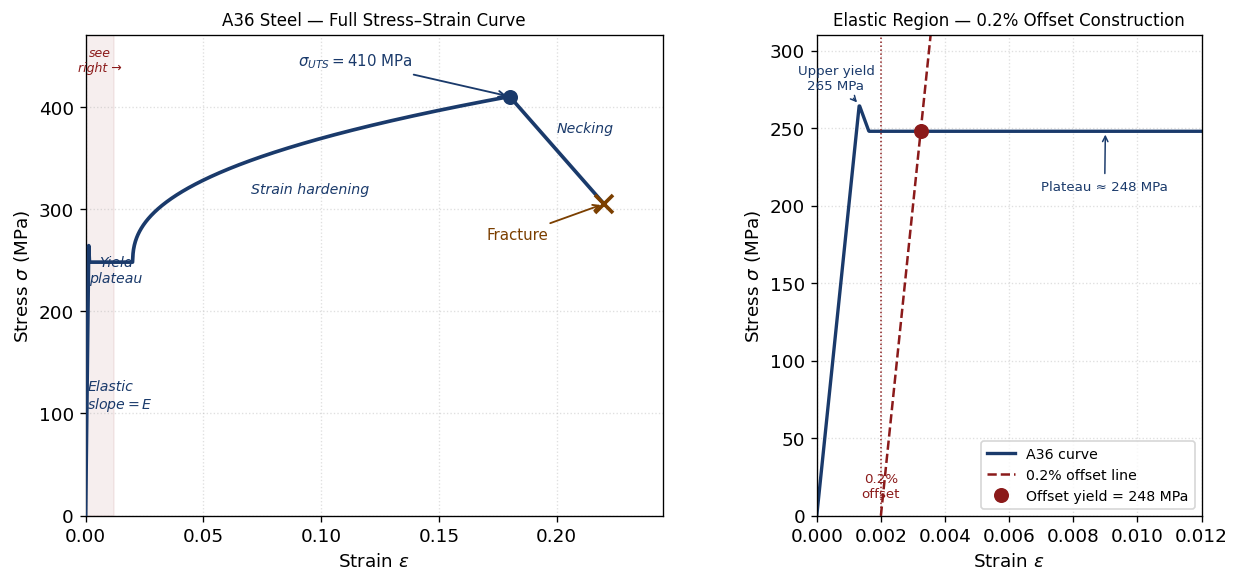

A36 offset yield: 248 MPa at ε = 0.00324 (3238 με)


In [2]:
# === Figure 16.2: A36 steel stress–strain curve — two-panel layout ===
# Left: full range with all labeled regions
# Right: elastic/yield zoom showing the 0.2% offset construction clearly
E_MPa = 200_000.0        # Young's modulus of A36 steel, MPa
OFFSET_STRAIN = 0.002    # 0.2% offset used to define the yield strength

# A36 piecewise geometry (ASTM A36: Fy ≥ 250 MPa / 36 ksi, Fu 400–550 MPa)
eps_yield_upper = 265.0 / E_MPa          # strain at top of upper yield spike
sig_yield_upper = 265.0                  # MPa
eps_drop_end    = eps_yield_upper + 0.0003
sig_plateau     = 248.0                  # MPa  lower yield / Lüders plateau (≈ 36 ksi)
eps_plateau_end = 0.020
sig_UTS         = 410.0                  # MPa  (within A36 range 400–550 MPa)
eps_UTS         = 0.18
sig_fracture    = 305.0                  # MPa  (engineering stress at neck fracture)
eps_fracture    = 0.22

def a36(e_arr):
    """Engineering stress (MPa) for an A36 steel specimen at each strain in ``e_arr``.

    Implements the idealized piecewise A36 response: linear elastic loading, an
    upper-yield spike that drops to the Lüders plateau, a power-law strain-hardening
    rise to the ultimate tensile strength, then a linear fall to fracture. Strains
    beyond fracture return NaN.
    """
    out = np.zeros_like(e_arr, dtype=float)
    for i, e in enumerate(e_arr):
        if e <= eps_yield_upper:
            out[i] = E_MPa * e
        elif e <= eps_drop_end:
            t = (e - eps_yield_upper) / (eps_drop_end - eps_yield_upper)
            out[i] = sig_yield_upper * (1.0 - t) + sig_plateau * t
        elif e <= eps_plateau_end:
            out[i] = sig_plateau
        elif e <= eps_UTS:
            t = (e - eps_plateau_end) / (eps_UTS - eps_plateau_end)
            out[i] = sig_plateau + (sig_UTS - sig_plateau) * t**0.42
        elif e <= eps_fracture:
            t = (e - eps_UTS) / (eps_fracture - eps_UTS)
            out[i] = sig_UTS + (sig_fracture - sig_UTS) * t
        else:
            out[i] = np.nan
    return out

eps_full = np.linspace(0, eps_fracture, 2000)
sig_full = a36(eps_full)

# 0.2% offset intersection: where the offset line (slope E, shifted by OFFSET_STRAIN)
# first crosses the stress–strain curve.
eps_search = np.linspace(OFFSET_STRAIN, 0.030, 10000)
diff = a36(eps_search) - E_MPa * (eps_search - OFFSET_STRAIN)
idx  = np.where(np.diff(np.sign(diff)))[0]
eps_y_off = float(eps_search[idx[0]])
sig_y_off = float(a36(np.array([eps_y_off]))[0])

NAVY     = '#1a3a6b'
DARK_RED = '#8b1a1a'
BROWN    = '#7b3f00'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2),
                                gridspec_kw={'width_ratios': [3, 2]})
fig.subplots_adjust(wspace=0.32)

# ── Left panel: full curve ────────────────────────────────────────────────────
ax1.plot(eps_full, sig_full, color=NAVY, lw=2.2, zorder=3)
ax1.plot(eps_UTS,      sig_UTS,      'o', color=NAVY,  ms=8,  zorder=5)
ax1.plot(eps_fracture, sig_fracture, 'x', color=BROWN, ms=11, mew=2.2, zorder=5)

ax1.annotate(f'$\\sigma_{{UTS}}={sig_UTS:.0f}$ MPa',
             xy=(eps_UTS, sig_UTS), xytext=(0.09, 440),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1),
             color=NAVY, fontsize=9)
ax1.annotate('Fracture',
             xy=(eps_fracture, sig_fracture), xytext=(0.17, 270),
             arrowprops=dict(arrowstyle='->', color=BROWN, lw=1.1),
             color=BROWN, fontsize=9)

ax1.text(0.0008, 105, 'Elastic\n$slope=E$', color=NAVY, fontsize=8.5, style='italic')
ax1.text(0.013,  228, 'Yield\nplateau',      color=NAVY, fontsize=8.5, style='italic', ha='center')
ax1.text(0.070,  315, 'Strain hardening',    color=NAVY, fontsize=8.5, style='italic')
ax1.text(0.200,  375, 'Necking',             color=NAVY, fontsize=8.5, style='italic')

# shade zoom region
ax1.axvspan(0, 0.012, alpha=0.07, color=DARK_RED, zorder=0)
ax1.text(0.006, 435, 'see\nright →', color=DARK_RED, fontsize=7.5, ha='center', style='italic')

ax1.set_xlabel('Strain $\\varepsilon$', fontsize=11)
ax1.set_ylabel('Stress $\\sigma$ (MPa)', fontsize=11)
ax1.set_xlim(0, 0.245);  ax1.set_ylim(0, 470)
ax1.grid(True, ls=':', alpha=0.40)
ax1.set_title('A36 Steel — Full Stress–Strain Curve', fontsize=10)

# ── Right panel: elastic / yield zoom ─────────────────────────────────────────
eps_z  = np.linspace(0, 0.012, 800)
sig_z  = a36(eps_z)
eps_oz = np.linspace(OFFSET_STRAIN, eps_y_off + 0.0015, 100)
sig_oz = E_MPa * (eps_oz - OFFSET_STRAIN)

ax2.plot(eps_z,  sig_z,  color=NAVY,     lw=2.0, label='A36 curve')
ax2.plot(eps_oz, sig_oz, color=DARK_RED, lw=1.5, ls='--', label='0.2% offset line')
ax2.plot(eps_y_off, sig_y_off, 'o', color=DARK_RED, ms=8, zorder=5,
         label=f'Offset yield = {sig_y_off:.0f} MPa')
ax2.axvline(OFFSET_STRAIN, color=DARK_RED, lw=0.9, ls=':')
ax2.text(OFFSET_STRAIN, 12, '0.2%\noffset', color=DARK_RED, fontsize=8, ha='center')

# Upper yield annotation — text placed right of the spike, below the spike peak
ax2.annotate(f'Upper yield\n{sig_yield_upper:.0f} MPa',
             xy=(eps_yield_upper, sig_yield_upper),
             xytext=(0.0006, 275),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=0.9),
             color=NAVY, fontsize=8, ha='center')
# Plateau annotation — to the right, mid-plateau
ax2.annotate(f'Plateau ≈ {sig_plateau:.0f} MPa',
             xy=(0.009, sig_plateau),
             xytext=(0.007, 210),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=0.9),
             color=NAVY, fontsize=8)

ax2.set_xlabel('Strain $\\varepsilon$', fontsize=11)
ax2.set_ylabel('Stress $\\sigma$ (MPa)', fontsize=11)
ax2.set_xlim(0, 0.012);  ax2.set_ylim(0, 310)
ax2.grid(True, ls=':', alpha=0.40)
# Legend bottom-right, clear of spike and offset construction
ax2.legend(fontsize=8.5, loc='lower right')
ax2.set_title('Elastic Region — 0.2% Offset Construction', fontsize=10)

plt.savefig(OUT_DIR / 'fig16_1_stress_strain_curve.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"A36 offset yield: {sig_y_off:.0f} MPa at ε = {eps_y_off:.5f} ({eps_y_off*1e6:.0f} με)")

---
## 1 — Stress–Strain Curve and 0.2% Offset Yield Point

The left panel shows the complete stress–strain curve from elastic loading through the plastic plateau and up to the ultimate stress. The right panel zooms into the elastic region where the 0.2% offset method is applied. The offset line has the same slope as the elastic modulus but is shifted 0.002 (0.2%) along the strain axis — visually, it is a copy of the elastic line moved to the right. Where this line crosses the stress–strain curve is the yield point.

The method was standardized because many metals — particularly those without a sharp yield discontinuity — do not have an obvious "kink" where elastic behavior ends. The 0.2% offset provides a reproducible proxy for the practical onset of permanent deformation. In strain gage terms, this is the point beyond which a gage measurement can no longer be interpreted as purely elastic: past yield, the material retains some permanent deformation when unloaded, and Hooke's law no longer applies.

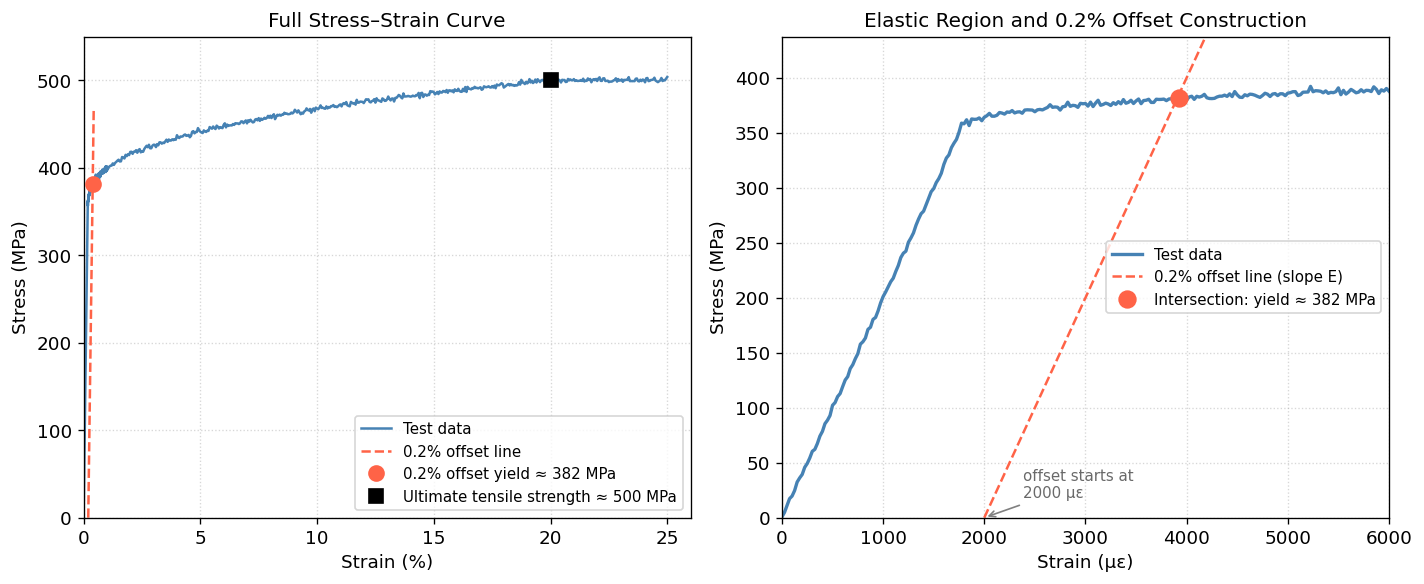

0.2% offset yield strength: 381.6 MPa at ε = 3925 με
Ultimate tensile strength:  500.0 MPa at ε = 20.0 %
Young's modulus from linear fit of elastic region: 200 GPa


In [3]:
# === Figure 16.3: a representative smooth-yielding steel ===
# Unlike the A36 curve above, this material has no sharp knee — which is exactly
# why the 0.2% offset convention is needed to define a reproducible yield point.
np.random.seed(42)   # deterministic measurement noise

E       = 200e3   # Young's modulus, MPa
sigma_y = 350     # nominal yield stress, MPa
sigma_u = 500     # ultimate stress, MPa
eps_u   = 0.20    # strain at ultimate stress
OFFSET_STRAIN = 0.002   # 0.2% offset
HARDENING_EXP = 0.35    # power-law strain-hardening exponent
NOISE_MPA     = 1.5     # std. dev. of simulated measurement noise, MPa

def stress_strain_model(eps, E, sy, su, eu, hardening_exp=HARDENING_EXP):
    """Engineering stress (MPa) for a smooth-yielding steel over a strain array.

    Linear elastic below the yield strain ``sy/E``; above it, a power-law hardening
    branch rises from ``sy`` toward the ultimate stress ``su``, capped at ``su``.
    Deliberately has no distinct yield plateau so the 0.2% offset construction is
    the only well-defined way to report a yield strength.
    """
    sigma = np.zeros_like(eps)
    elastic = eps < sy / E
    sigma[elastic] = E * eps[elastic]
    inelastic = ~elastic
    eps_in = eps[inelastic]
    sigma[inelastic] = sy + (su - sy) * ((eps_in - sy / E) / (eu - sy / E))**hardening_exp
    sigma = np.minimum(sigma, su)
    return sigma

# Strain grid: fine through the elastic/yield region (where the offset construction
# lives), coarser along the long plastic tail.
eps = np.concatenate([np.linspace(0, 0.01, 401), np.linspace(0.01, 0.25, 481)[1:]])
sigma = stress_strain_model(eps, E, sigma_y, sigma_u, eps_u)
sigma += np.random.normal(0, NOISE_MPA, sigma.shape)  # add measurement noise

# 0.2% offset line: slope E, starting at zero stress at eps = OFFSET_STRAIN
def offset_line(e):
    return E * (e - OFFSET_STRAIN)

# Yield point: first point past the offset strain where the test curve drops
# below the offset line (the curve crosses it from above).
past = np.where(eps > OFFSET_STRAIN)[0]
cross = past[np.argmax(sigma[past] <= offset_line(eps[past]))]
eps_y, sig_y = eps[cross], sigma[cross]

# Draw the offset line from zero stress up to (just beyond) the intersection.
eps_offset = np.linspace(OFFSET_STRAIN, eps_y + 0.0004, 100)
sigma_offset = offset_line(eps_offset)

# Ultimate tensile strength: the peak of the underlying (noise-free) curve, which
# the model reaches at eps_u and holds thereafter.
eps_uts, sig_uts = eps_u, float(sigma_u)

# Recover E from the noisy elastic points, exactly as a real tensile test would.
elastic_pts = (eps > 0) & (eps < 0.8 * sigma_y / E)
E_fit = np.polyfit(eps[elastic_pts], sigma[elastic_pts], 1)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(eps*100, sigma, 'steelblue', lw=1.5, label='Test data')
axes[0].plot(eps_offset*100, sigma_offset, 'tomato', lw=1.5, linestyle='--', label='0.2% offset line')
axes[0].plot(eps_y*100, sig_y, 'o', color='tomato', markersize=9, zorder=5,
             label=f'0.2% offset yield ≈ {sig_y:.0f} MPa')
axes[0].plot(eps_uts*100, sig_uts, 's', color='black', markersize=8, zorder=5,
             label=f'Ultimate tensile strength ≈ {sig_uts:.0f} MPa')
axes[0].set_xlabel('Strain (%)'); axes[0].set_ylabel('Stress (MPa)')
axes[0].set_title('Full Stress–Strain Curve'); axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_xlim(0, 26); axes[0].set_ylim(0, sigma_u*1.1)
axes[0].grid(True, linestyle=':', alpha=0.5)

# Elastic / yield detail: the offset line runs from 2000 με at zero stress up to
# its intersection with the curve, which defines the yield strength.
detail = eps <= 0.006
axes[1].plot(eps[detail]*1e6, sigma[detail], 'steelblue', lw=2, label='Test data')
axes[1].plot(eps_offset*1e6, sigma_offset, 'tomato', lw=1.5, linestyle='--', label='0.2% offset line (slope E)')
axes[1].plot(eps_y*1e6, sig_y, 'o', color='tomato', markersize=10, zorder=5,
             label=f'Intersection: yield ≈ {sig_y:.0f} MPa')
axes[1].annotate('offset starts at\n2000 με', xy=(OFFSET_STRAIN*1e6, 0), xytext=(2380, 18),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='dimgray')
axes[1].set_xlim(0, 6000); axes[1].set_ylim(0, sigma_y * 1.25)
axes[1].set_xlabel('Strain (με)'); axes[1].set_ylabel('Stress (MPa)')
axes[1].set_title('Elastic Region and 0.2% Offset Construction'); axes[1].legend(fontsize=9, loc='center right')
axes[1].grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.savefig(OUT_DIR / 'fig16_nb1_stress_strain_curve_yield.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"0.2% offset yield strength: {sig_y:.1f} MPa at ε = {eps_y*1e6:.0f} με")
print(f"Ultimate tensile strength:  {sig_uts:.1f} MPa at ε = {eps_uts*100:.1f} %")
print(f"Young's modulus from linear fit of elastic region: {E_fit/1000:.0f} GPa")

---
## Where to take this next

These curves are a starting point — the physics is easy to extend once the pieces are named constants and functions:

1. **Overlay true stress and true strain.** The chapter gives the conversions $\sigma_{\text{true}} = \sigma_{\text{eng}}(1+\varepsilon_{\text{eng}})$ and $\varepsilon_{\text{true}} = \ln(1+\varepsilon_{\text{eng}})$ (Eqs. 16.1–16.2). Plot both alongside the engineering curve and watch them diverge past a few percent strain — and note where the conversion stops being valid once necking begins.
2. **Extract toughness and resilience by integration.** Numerically integrate stress over strain (`np.trapezoid`; `np.trapz` in NumPy < 2) up to yield for the *modulus of resilience*, and up to fracture for the *toughness*. Compare the ductile A36 curve against a brittle material with the same modulus but no plastic region.
3. **Test the offset method against noise and sampling.** Sweep `NOISE_MPA` and the strain-grid resolution, re-run the offset construction many times, and plot the scatter in the recovered yield strength — a direct, hands-on illustration of why a *convention* beats eyeballing the knee.